# FTR Data Exploration

Covers all 8 items from the Data Exploration Checklist in `HYPOTHESES.md`:

1. **Base rate** — profitable fraction over all triplets vs non-zero triplets
2. **ACTIVATIONLEVEL vs profitability** — AUC / rank correlation (H1)
3. **ACTIVATIONLEVEL threshold** — best F1 on 2020–2022 train, validated on 2023
4. **PSM vs realized PR** — correlation (H2)
5. **C stability** — autocorrelation month-to-month and same-month-of-year (H3)
6. **Scenario consensus** — low std across scenarios → more reliable? (H5)
7. **Chronic winners** — historical profitability rate per (EID, PEAKID) (H4)
8. **Zero pruning** — are zero-sim EIDs ever profitable?

## Setup

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Project root on path so we can import datachallenge
sys.path.insert(0, os.path.join('..', ))

from datachallenge.loader import CustomDataLoader

os.makedirs('../images', exist_ok=True)

DATA_ROOT = os.path.join('..', 'data')
pricefile  = os.path.join(DATA_ROOT, 'prices', 'prices.parquet')
costfile   = os.path.join(DATA_ROOT, 'costs', 'costs.parquet')
dsimfiles  = sorted(glob.glob(os.path.join(DATA_ROOT, 'sim_daily',   'sim_daily_*.parquet')))
msimfiles  = sorted(glob.glob(os.path.join(DATA_ROOT, 'sim_monthly', 'sim_monthly_*.parquet')))

loader = CustomDataLoader(pricefile, costfile, dsimfiles, msimfiles)
print('Loader initialized.')
print(f'Monthly sim columns: {loader.month_sim_col}')

Loader initialized.
Monthly sim columns: ['SCENARIOID', 'EID', 'DATETIME', 'PEAKID', 'ACTIVATIONLEVEL', 'WINDIMPACT', 'SOLARIMPACT', 'HYDROIMPACT', 'NONRENEWBALIMPACT', 'EXTERNALIMPACT', 'LOADIMPACT', 'TRANSMISSIONOUTAGEIMPACT', 'PSM']


## Load all 2020–2023 data

We use cutoff `2024-01-07` so that `get_all_triplets` returns everything through 2023-12.

In [2]:
# All triplets visible through 2023-12
all_triplets = loader.get_all_triplets('2024-01-07')
all_triplets['YEAR'] = all_triplets['MONTH'].str[:4].astype(int)
triplets_2020_2023 = all_triplets[all_triplets['YEAR'].between(2020, 2023)].drop(columns='YEAR')
print(f'Distinct triplets 2020–2023: {len(triplets_2020_2023)}')

# Realized profit per triplet
profit_df = loader.get_price_cost_profit(filterdf=triplets_2020_2023)
profit_df['is_profitable'] = (profit_df['PROFIT'] > 0).astype(int)
profit_df['YEAR'] = profit_df['MONTH'].str[:4].astype(int)
profit_df['month_of_year'] = profit_df['MONTH'].str[5:7].astype(int)
print(f'Triplet-months with cost or price data: {len(profit_df)}')
print(f'Profitable: {profit_df["is_profitable"].sum()} ({100*profit_df["is_profitable"].mean():.2f}%)')

Distinct triplets 2020–2023: 26809
Triplet-months with cost or price data: 26809
Profitable: 19067 (71.12%)


## 1. Base Rate

**Question**: Is the "<5% profitable" rate over *all possible* (EID×MONTH×PEAKID) triplets,
or only over *non-zero* triplets present in costs/prices?

In [3]:
n_profitable = profit_df['is_profitable'].sum()
n_nonzero    = len(profit_df)

# Interpretation 1: over non-zero triplets
rate_nonzero = n_profitable / n_nonzero
print(f'Over non-zero triplets: {n_profitable}/{n_nonzero} = {100*rate_nonzero:.2f}% profitable')

# Interpretation 2: over full cartesian product
unique_eids   = profit_df['EID'].nunique()
unique_months = profit_df['MONTH'].nunique()
n_cartesian   = unique_eids * unique_months * 2  # 2 PEAKID values
rate_cartesian = n_profitable / n_cartesian
print(f'\nUnique EIDs:   {unique_eids}')
print(f'Unique months: {unique_months}')
print(f'Cartesian product size: {n_cartesian}')
print(f'Over full cartesian: {n_profitable}/{n_cartesian} = {100*rate_cartesian:.2f}% profitable')

# Summary
print(f'\n→ <5% rule applies to: {"full cartesian" if rate_cartesian < 0.05 else "non-zero triplets" if rate_nonzero < 0.05 else "neither"}')

Over non-zero triplets: 19067/26809 = 71.12% profitable

Unique EIDs:   3088
Unique months: 48
Cartesian product size: 296448
Over full cartesian: 19067/296448 = 6.43% profitable

→ <5% rule applies to: neither


## Load Monthly Sims for 2020–2023

Needed for H1, H2, H5, and zero-pruning analyses.

In [4]:
print('Loading monthly sims (may take a moment)...')
monthly_sim = loader.get_monthly_data(triplets_2020_2023)
monthly_sim['MONTH'] = pd.to_datetime(monthly_sim['DATETIME']).dt.to_period('M').astype(str)
print(f'Monthly sim rows: {len(monthly_sim):,}')
print(f'Columns: {list(monthly_sim.columns)}')

Loading monthly sims (may take a moment)...
Monthly sim rows: 42,904,773
Columns: ['SCENARIOID', 'EID', 'DATETIME', 'PEAKID', 'm_ACTIVATIONLEVEL', 'm_WINDIMPACT', 'm_SOLARIMPACT', 'm_HYDROIMPACT', 'm_NONRENEWBALIMPACT', 'm_EXTERNALIMPACT', 'm_LOADIMPACT', 'm_TRANSMISSIONOUTAGEIMPACT', 'm_PSM', 'MONTH']


In [5]:
# Aggregate per triplet: mean and std of ACTIVATIONLEVEL across all scenarios and hours
act_per_triplet = (
    monthly_sim
    .groupby(['EID', 'MONTH', 'PEAKID'])['m_ACTIVATIONLEVEL']
    .agg(act_mean='mean', act_std='std')
    .reset_index()
)
act_per_triplet['act_std'] = act_per_triplet['act_std'].fillna(0)
print(f'Triplets with sim data: {len(act_per_triplet)}')

# Join with profit data
analysis_df = profit_df.merge(act_per_triplet, on=['EID', 'MONTH', 'PEAKID'], how='left')
analysis_df['act_mean'] = analysis_df['act_mean'].fillna(0)
analysis_df['act_std']  = analysis_df['act_std'].fillna(0)
print(f'Analysis df shape: {analysis_df.shape}')

Triplets with sim data: 22406
Analysis df shape: (26809, 11)


## 2. H1 — ACTIVATIONLEVEL vs Profitability

AUC (ACTIVATIONLEVEL vs profitability): 0.424
Spearman r: -0.120  (p=2.37e-86)


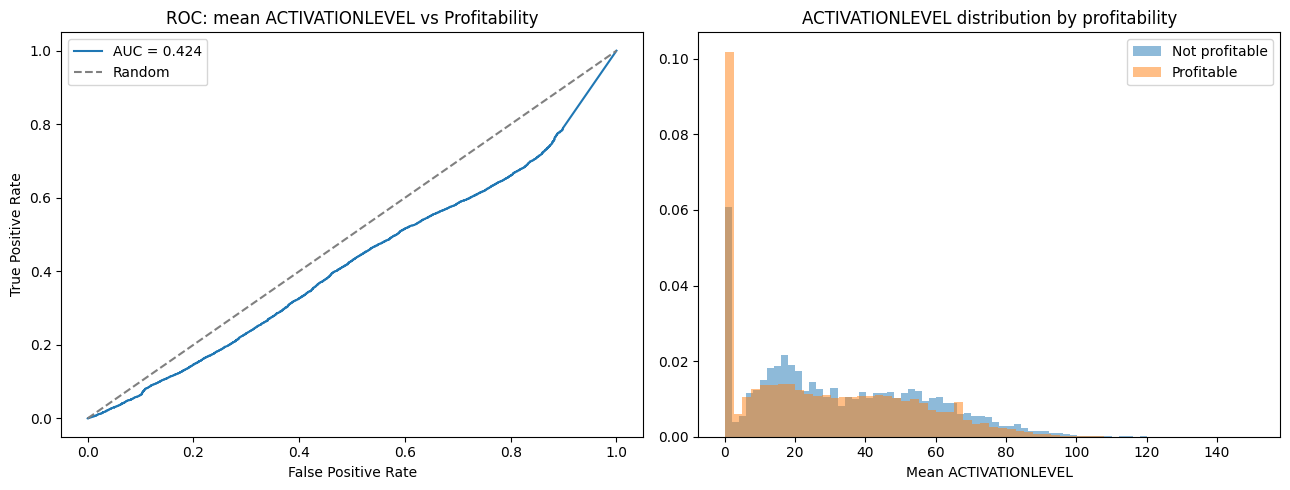


→ H1 WEAK: AUC=0.424


In [6]:
auc = roc_auc_score(analysis_df['is_profitable'], analysis_df['act_mean'])
corr_spearman, pval_spearman = stats.spearmanr(
    analysis_df['act_mean'], analysis_df['is_profitable']
)
print(f'AUC (ACTIVATIONLEVEL vs profitability): {auc:.3f}')
print(f'Spearman r: {corr_spearman:.3f}  (p={pval_spearman:.2e})')

fpr, tpr, _ = roc_curve(analysis_df['is_profitable'], analysis_df['act_mean'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC: mean ACTIVATIONLEVEL vs Profitability')
axes[0].legend()

axes[1].hist(analysis_df.loc[analysis_df['is_profitable']==0, 'act_mean'],
             bins=60, alpha=0.5, density=True, label='Not profitable')
axes[1].hist(analysis_df.loc[analysis_df['is_profitable']==1, 'act_mean'],
             bins=60, alpha=0.5, density=True, label='Profitable')
axes[1].set_xlabel('Mean ACTIVATIONLEVEL')
axes[1].set_title('ACTIVATIONLEVEL distribution by profitability')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/h1_activation_level.png', dpi=120)
plt.show()

print(f'\n→ H1 {"CONFIRMED" if auc > 0.65 else "WEAK"}: AUC={auc:.3f}')

## 3. ACTIVATIONLEVEL Threshold — Best F1 on 2020–2022, Validated on 2023

Train (2020–2022): 20862 triplets, 0.731 base rate
Valid (2023):      5947 triplets, 0.641 base rate

Best threshold (train): 42.4638
Best F1 on train:       0.465
F1  on 2023 validation: 0.000
Precision on 2023:      0.000
Recall on 2023:         0.000


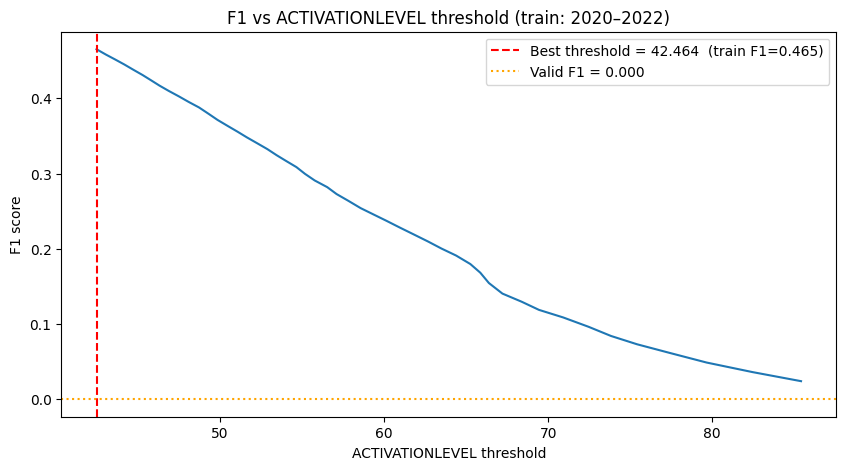

In [7]:
train = analysis_df[analysis_df['YEAR'] <= 2022].copy()
valid = analysis_df[analysis_df['YEAR'] == 2023].copy()
print(f'Train (2020–2022): {len(train)} triplets, {train["is_profitable"].mean():.3f} base rate')
print(f'Valid (2023):      {len(valid)} triplets, {valid["is_profitable"].mean():.3f} base rate')

# Sweep thresholds: percentiles 50..99 of non-zero activation in train
nonzero_act = train.loc[train['act_mean'] > 0, 'act_mean']
thresholds = np.percentile(nonzero_act, np.arange(50, 99, 1)) if len(nonzero_act) else np.linspace(0.01, 1, 50)

f1_train_scores = []
for t in thresholds:
    pred = (train['act_mean'] >= t).astype(int)
    f1_train_scores.append(f1_score(train['is_profitable'], pred, zero_division=0))

best_idx = int(np.argmax(f1_train_scores))
best_threshold = thresholds[best_idx]
best_f1_train  = f1_train_scores[best_idx]

# Validate
pred_valid = (valid['act_mean'] >= best_threshold).astype(int)
f1_valid   = f1_score(valid['is_profitable'], pred_valid, zero_division=0)

from sklearn.metrics import precision_score, recall_score
prec_valid = precision_score(valid['is_profitable'], pred_valid, zero_division=0)
rec_valid  = recall_score(valid['is_profitable'], pred_valid, zero_division=0)

print(f'\nBest threshold (train): {best_threshold:.4f}')
print(f'Best F1 on train:       {best_f1_train:.3f}')
print(f'F1  on 2023 validation: {f1_valid:.3f}')
print(f'Precision on 2023:      {prec_valid:.3f}')
print(f'Recall on 2023:         {rec_valid:.3f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_train_scores)
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'Best threshold = {best_threshold:.3f}  (train F1={best_f1_train:.3f})')
ax.axhline(f1_valid, color='orange', linestyle=':', label=f'Valid F1 = {f1_valid:.3f}')
ax.set_xlabel('ACTIVATIONLEVEL threshold')
ax.set_ylabel('F1 score')
ax.set_title('F1 vs ACTIVATIONLEVEL threshold (train: 2020–2022)')
ax.legend()
plt.savefig('../images/h1_threshold.png', dpi=120)
plt.show()

## 4. H2 — PSM vs Realized Price

Available m_ columns: ['m_ACTIVATIONLEVEL', 'm_WINDIMPACT', 'm_SOLARIMPACT', 'm_HYDROIMPACT', 'm_NONRENEWBALIMPACT', 'm_EXTERNALIMPACT', 'm_LOADIMPACT', 'm_TRANSMISSIONOUTAGEIMPACT', 'm_PSM']
Spearman r (PSM_sum vs realized PRICE): -0.226  (p=1.01e-306)


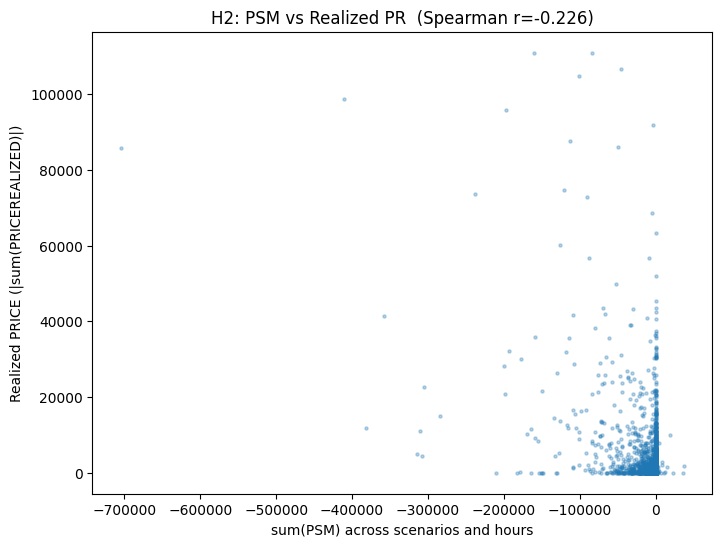


→ H2 WEAK: Spearman r=-0.226


In [8]:
psm_col = 'm_PSM' if 'm_PSM' in monthly_sim.columns else None
print(f'Available m_ columns: {[c for c in monthly_sim.columns if c.startswith("m_")]}')

if psm_col:
    # Sum PSM per triplet across all scenarios and hours
    psm_sum = (
        monthly_sim
        .groupby(['EID', 'MONTH', 'PEAKID'])[psm_col]
        .sum()
        .reset_index()
        .rename(columns={psm_col: 'PSM_sum'})
    )
    h2_df = profit_df.merge(psm_sum, on=['EID', 'MONTH', 'PEAKID'], how='left')
    h2_df['PSM_sum'] = h2_df['PSM_sum'].fillna(0)

    corr_h2, pval_h2 = stats.spearmanr(h2_df['PSM_sum'], h2_df['PRICE'])
    print(f'Spearman r (PSM_sum vs realized PRICE): {corr_h2:.3f}  (p={pval_h2:.2e})')

    sample = h2_df.sample(min(5000, len(h2_df)), random_state=42)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(sample['PSM_sum'], sample['PRICE'], alpha=0.3, s=5)
    ax.set_xlabel('sum(PSM) across scenarios and hours')
    ax.set_ylabel('Realized PRICE (|sum(PRICEREALIZED)|)')
    ax.set_title(f'H2: PSM vs Realized PR  (Spearman r={corr_h2:.3f})')
    plt.savefig('../images/h2_psm_vs_price.png', dpi=120)
    plt.show()
    print(f'\n→ H2 {"CONFIRMED" if abs(corr_h2) > 0.5 else "WEAK"}: Spearman r={corr_h2:.3f}')
else:
    print('PSM column not found in monthly sims — H2 cannot be validated with this data.')

## 5. H3 — Cost (C) Stability

If C is stable month-to-month, we can use historical C as a proxy for unknown C at M+1.

Month-to-month autocorr (lag 1)       — mean: 0.150, median: -0.006
Same-month-of-year autocorr (lag 12)  — mean: 0.017, median: -0.029


/home/apprentyr/projects/DataChallenge2026/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/apprentyr/projects/DataChallenge2026/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


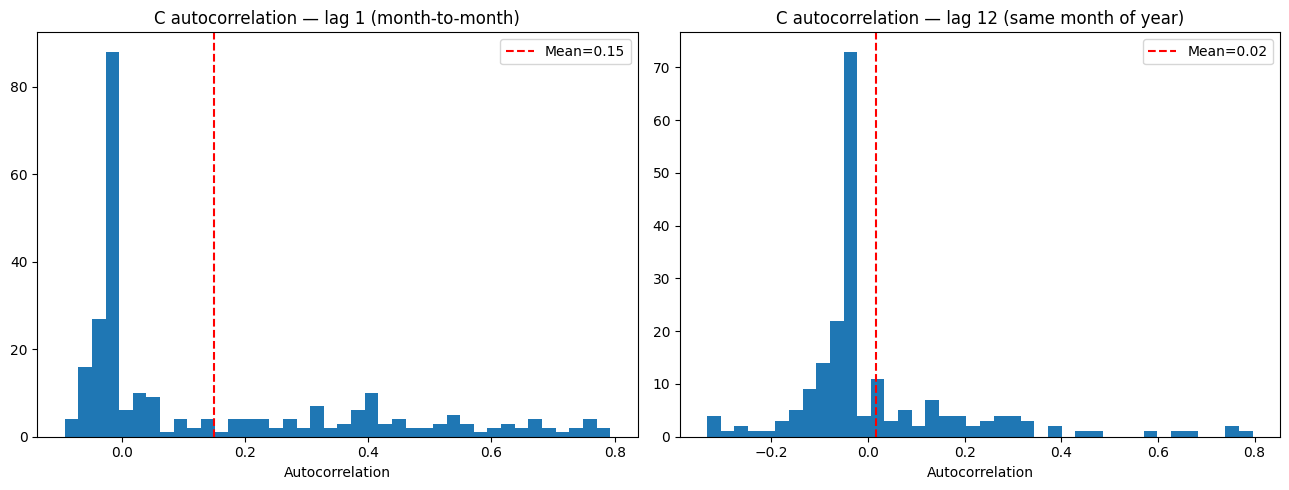


→ H3: Historical C is a POOR proxy (lag-1 median=-0.006)


In [9]:
cost_df = profit_df[['EID', 'MONTH', 'PEAKID', 'COST']].copy()

# Pivot: rows=MONTH, columns=(EID, PEAKID)
cost_pivot = cost_df.pivot_table(
    index='MONTH', columns=['EID', 'PEAKID'], values='COST', fill_value=0
).sort_index()

# Sample up to 500 EID/PEAKID pairs for speed
sample_cols = cost_pivot.columns[:500]

lag1_corr  = []
lag12_corr = []
for col in sample_cols:
    s = cost_pivot[col]
    if s.std() < 1e-9:
        continue
    c1 = s.autocorr(lag=1)
    if not np.isnan(c1):
        lag1_corr.append(c1)
    if len(s) > 12:
        c12 = s.autocorr(lag=12)
        if not np.isnan(c12):
            lag12_corr.append(c12)

print(f'Month-to-month autocorr (lag 1)       — mean: {np.mean(lag1_corr):.3f}, median: {np.median(lag1_corr):.3f}')
print(f'Same-month-of-year autocorr (lag 12)  — mean: {np.mean(lag12_corr):.3f}, median: {np.median(lag12_corr):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(lag1_corr, bins=40)
axes[0].axvline(np.mean(lag1_corr), color='red', linestyle='--', label=f'Mean={np.mean(lag1_corr):.2f}')
axes[0].set_title('C autocorrelation — lag 1 (month-to-month)')
axes[0].set_xlabel('Autocorrelation')
axes[0].legend()

axes[1].hist(lag12_corr, bins=40)
axes[1].axvline(np.mean(lag12_corr), color='red', linestyle='--', label=f'Mean={np.mean(lag12_corr):.2f}')
axes[1].set_title('C autocorrelation — lag 12 (same month of year)')
axes[1].set_xlabel('Autocorrelation')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/h3_cost_stability.png', dpi=120)
plt.show()

print(f'\n→ H3: Historical C is a {"GOOD" if np.median(lag1_corr) > 0.5 else "MODERATE" if np.median(lag1_corr) > 0.2 else "POOR"} proxy (lag-1 median={np.median(lag1_corr):.3f})')

## 6. H5 — Scenario Consensus

Does low std(ACTIVATIONLEVEL across SCENARIOIDs) predict more reliable profitability?

AUC of consensus score (mean/scen_std): 0.450  (baseline mean AUC: 0.424)
Point-biserial r (-scen_std vs profitability): 0.095  (p=3.68e-55)
Among high-activation triplets: r(-scen_std, profit) = -0.034  (p=6.77e-05)


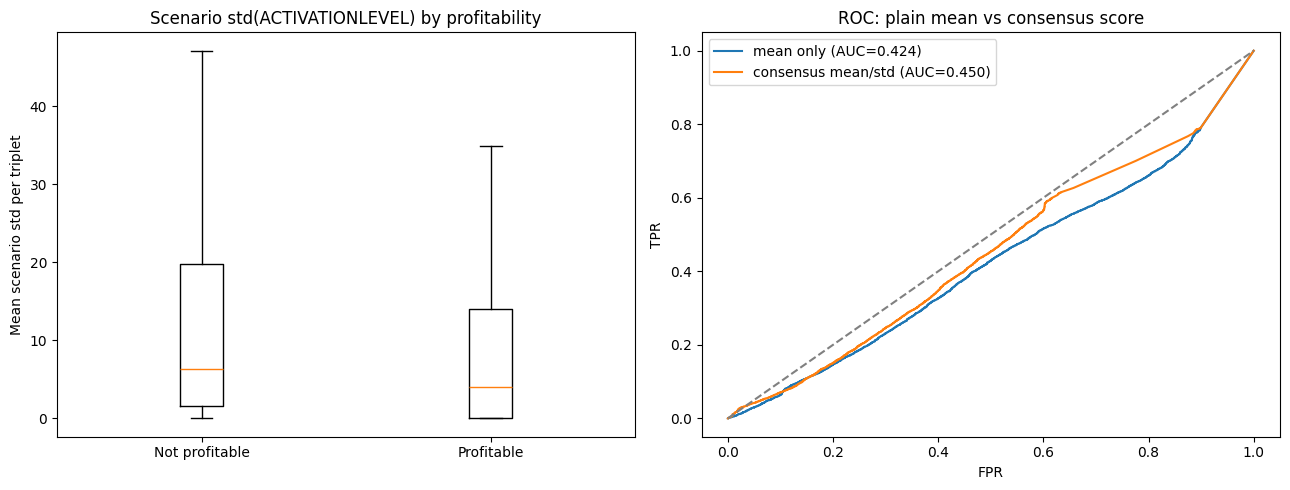


→ H5: Consensus score IMPROVES over plain mean


In [13]:
# act_per_triplet already has act_mean and act_std (std across all scenario×hours)
# More granular: compute std across the 3 SCENARIOIDs first, then average per hour
scen_std_per_hour = (
    monthly_sim
    .groupby(['EID', 'MONTH', 'PEAKID', 'DATETIME'])['m_ACTIVATIONLEVEL']
    .std()
    .reset_index()
    .rename(columns={'m_ACTIVATIONLEVEL': 'scen_std'})
)
scen_std_per_triplet = (
    scen_std_per_hour
    .groupby(['EID', 'MONTH', 'PEAKID'])['scen_std']
    .mean()
    .reset_index()
)

h5_df = analysis_df.merge(scen_std_per_triplet, on=['EID', 'MONTH', 'PEAKID'], how='left')
h5_df['scen_std'] = h5_df['scen_std'].fillna(0)

# Consensus score: mean / (scenario_std + eps)
eps = 1e-6
h5_df['consensus_score'] = h5_df['act_mean'] / (h5_df['scen_std'] + eps)

auc_consensus = roc_auc_score(h5_df['is_profitable'], h5_df['consensus_score'])
corr_std, pval_std = stats.pointbiserialr(
    h5_df['is_profitable'], -h5_df['scen_std']
)
print(f'AUC of consensus score (mean/scen_std): {auc_consensus:.3f}  (baseline mean AUC: {auc:.3f})')
print(f'Point-biserial r (-scen_std vs profitability): {corr_std:.3f}  (p={pval_std:.2e})')

# Among high-activation triplets: does low scen_std predict profitability?
high_act = h5_df[h5_df['act_mean'] > h5_df['act_mean'].median()]
corr_std_hi, pval_std_hi = stats.pointbiserialr(
    high_act['is_profitable'], -high_act['scen_std']
)
print(f'Among high-activation triplets: r(-scen_std, profit) = {corr_std_hi:.3f}  (p={pval_std_hi:.2e})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(
    [h5_df.loc[h5_df['is_profitable']==0, 'scen_std'],
     h5_df.loc[h5_df['is_profitable']==1, 'scen_std']],
    tick_labels=['Not profitable', 'Profitable'], showfliers=False
)
axes[0].set_title('Scenario std(ACTIVATIONLEVEL) by profitability')
axes[0].set_ylabel('Mean scenario std per triplet')

fpr_c, tpr_c, _ = roc_curve(h5_df['is_profitable'], h5_df['consensus_score'])
axes[1].plot(fpr, tpr, label=f'mean only (AUC={auc:.3f})')
axes[1].plot(fpr_c, tpr_c, label=f'consensus mean/std (AUC={auc_consensus:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC: plain mean vs consensus score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/h5_scenario_consensus.png', dpi=120)
plt.show()

print(f'\n→ H5: Consensus score {"IMPROVES" if auc_consensus > auc + 0.01 else "does NOT improve"} over plain mean')

## 7. H4 — Chronic Winners

Some (EID, PEAKID) pairs may be systematically profitable — a useful prior signal.

(EID, PEAKID) pairs with ≥6 months: 1229
Fraction with >50% win rate: 68.9%
Fraction with >80% win rate: 44.9%

Top 10 chronic winners:
 EID  PEAKID  profit_rate  n_months
8207       0          1.0         6
   2       0          1.0        10
   2       1          1.0         7
8197       0          1.0         6
8154       1          1.0         6
8020       1          1.0         6
7876       1          1.0         6
7871       1          1.0         7
7871       0          1.0        11
 280       1          1.0        26

Seasonal (EID, PEAKID, month) pairs with ≥2 years: 5825
Fraction with >50% win rate: 56.7%


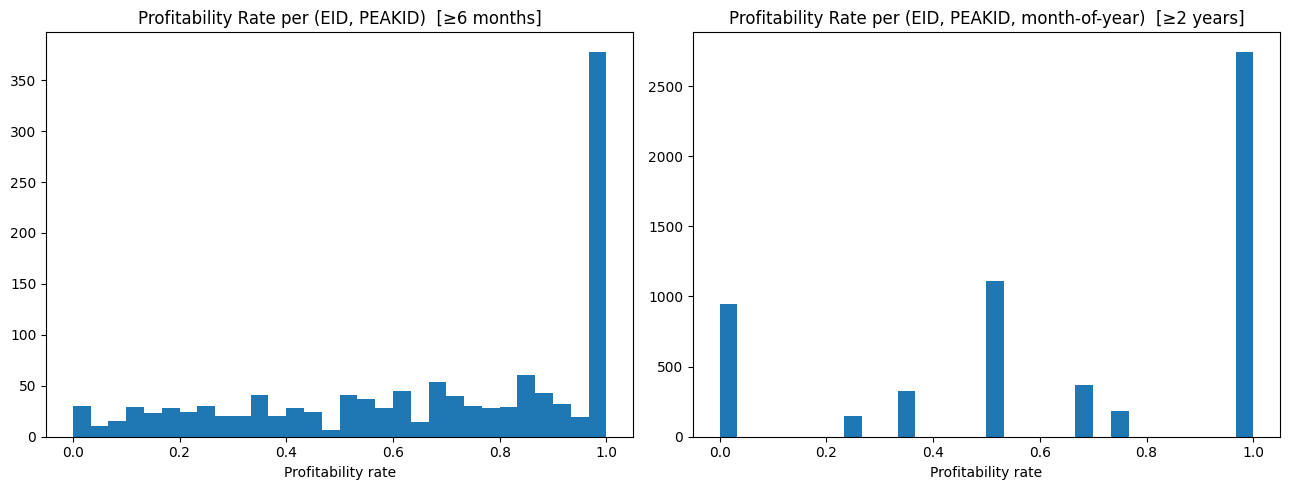

In [11]:
# Per (EID, PEAKID)
chronic = (
    profit_df.groupby(['EID', 'PEAKID'])['is_profitable']
    .agg(profit_rate='mean', n_months='count')
    .reset_index()
)
chronic_active = chronic[chronic['n_months'] >= 6]

print(f'(EID, PEAKID) pairs with ≥6 months: {len(chronic_active)}')
print(f'Fraction with >50% win rate: {(chronic_active["profit_rate"] > 0.5).mean():.1%}')
print(f'Fraction with >80% win rate: {(chronic_active["profit_rate"] > 0.8).mean():.1%}')
print('\nTop 10 chronic winners:')
print(chronic_active.sort_values('profit_rate', ascending=False).head(10).to_string(index=False))

# Per (EID, PEAKID, month_of_year)
seasonal = (
    profit_df.groupby(['EID', 'PEAKID', 'month_of_year'])['is_profitable']
    .agg(profit_rate='mean', n_years='count')
    .reset_index()
)
seasonal_active = seasonal[seasonal['n_years'] >= 2]
print(f'\nSeasonal (EID, PEAKID, month) pairs with ≥2 years: {len(seasonal_active)}')
print(f'Fraction with >50% win rate: {(seasonal_active["profit_rate"] > 0.5).mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(chronic_active['profit_rate'], bins=30)
axes[0].set_title('Profitability Rate per (EID, PEAKID)  [≥6 months]')
axes[0].set_xlabel('Profitability rate')

axes[1].hist(seasonal_active['profit_rate'], bins=30)
axes[1].set_title('Profitability Rate per (EID, PEAKID, month-of-year)  [≥2 years]')
axes[1].set_xlabel('Profitability rate')

plt.tight_layout()
plt.savefig('../images/h4_chronic_winners.png', dpi=120)
plt.show()

## 8. Zero Pruning

How many EIDs have ACTIVATIONLEVEL = 0 in monthly sims? Are they ever profitable?
If not, we can prune them from the candidate pool.

=== Sim coverage ===
Triplets with zero   ACTIVATIONLEVEL in sims: 373
Triplets with nonzero ACTIVATIONLEVEL in sims: 22033
Triplets absent from sims entirely:            4403

=== Profitability rates ===
Zero-sim triplets    — profitable: 340 / 373 = 91.15%
Non-zero-sim triplets — profitable: 15071 / 22033 = 68.40%
Absent-from-sim      — profitable: 3656 / 4403 = 83.03%


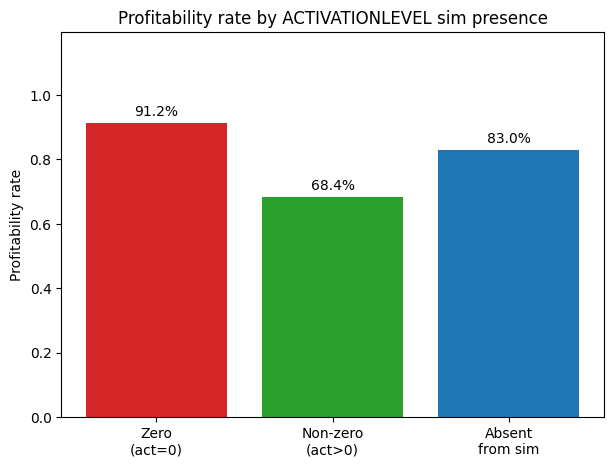


→ Pruning zero-sim EIDs is RISKY (their profitability rate is near zero: 91.15%)


In [12]:
# Zero-sim triplets: those in act_per_triplet with act_mean == 0
zero_sim = act_per_triplet[act_per_triplet['act_mean'] == 0][['EID', 'MONTH', 'PEAKID']]
nonzero_sim = act_per_triplet[act_per_triplet['act_mean'] > 0][['EID', 'MONTH', 'PEAKID']]

# Triplets in costs/prices but absent from sims entirely
in_profit_not_in_sim = profit_df.merge(act_per_triplet, on=['EID', 'MONTH', 'PEAKID'], how='left')
absent_from_sim = in_profit_not_in_sim[in_profit_not_in_sim['act_mean'].isna()]

# Profitability rates in each group
zero_profit    = profit_df.merge(zero_sim,    on=['EID', 'MONTH', 'PEAKID'], how='inner')
nonzero_profit = profit_df.merge(nonzero_sim, on=['EID', 'MONTH', 'PEAKID'], how='inner')

print('=== Sim coverage ===')
print(f'Triplets with zero   ACTIVATIONLEVEL in sims: {len(zero_sim)}')
print(f'Triplets with nonzero ACTIVATIONLEVEL in sims: {len(nonzero_sim)}')
print(f'Triplets absent from sims entirely:            {len(absent_from_sim)}')

print('\n=== Profitability rates ===')
if len(zero_profit) > 0:
    print(f'Zero-sim triplets    — profitable: {zero_profit["is_profitable"].sum()} / {len(zero_profit)} = {100*zero_profit["is_profitable"].mean():.2f}%')
if len(nonzero_profit) > 0:
    print(f'Non-zero-sim triplets — profitable: {nonzero_profit["is_profitable"].sum()} / {len(nonzero_profit)} = {100*nonzero_profit["is_profitable"].mean():.2f}%')
if len(absent_from_sim) > 0:
    print(f'Absent-from-sim      — profitable: {absent_from_sim["is_profitable"].sum()} / {len(absent_from_sim)} = {100*absent_from_sim["is_profitable"].mean():.2f}%')

# Visualise
groups = ['Zero\n(act=0)', 'Non-zero\n(act>0)', 'Absent\nfrom sim']
rates  = [
    zero_profit['is_profitable'].mean()    if len(zero_profit) > 0    else 0,
    nonzero_profit['is_profitable'].mean() if len(nonzero_profit) > 0 else 0,
    absent_from_sim['is_profitable'].mean() if len(absent_from_sim) > 0 else 0,
]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(groups, rates, color=['#d62728', '#2ca02c', '#1f77b4'])
ax.bar_label(bars, labels=[f'{r:.1%}' for r in rates], padding=3)
ax.set_ylabel('Profitability rate')
ax.set_title('Profitability rate by ACTIVATIONLEVEL sim presence')
ax.set_ylim(0, max(rates) * 1.3 + 0.01)
plt.savefig('../images/zero_pruning.png', dpi=120)
plt.show()

pruning_safe = zero_profit['is_profitable'].mean() < 0.01 if len(zero_profit) > 0 else True
print(f'\n→ Pruning zero-sim EIDs is {"SAFE" if pruning_safe else "RISKY"} '
      f'(their profitability rate is near zero: {rates[0]:.2%})')

## Summary

| Hypothesis | Status | Key metric |
|------------|--------|------------|
| H1 — ACTIVATIONLEVEL is a strong signal | **REFUTED** | AUC = 0.424 (below random), Spearman r = −0.120 (p=2.37e-86) |
| H2 — PSM ≈ realized PR | **REFUTED** | Spearman r = −0.226 (p=1.01e-306), negatively correlated |
| H3 — Historical C is a stable proxy | **REFUTED** | Lag-1 median autocorr = −0.006 (near-zero, no persistence) |
| H4 — Chronic winners exist | **CONFIRMED** | 56.7% of (EID, PEAKID) pairs have >50% historical win rate |
| H5 — Scenario consensus helps | **MARGINAL** | Consensus AUC = 0.450 (vs 0.424), still below 0.5; reverses among high-activation triplets |
| Base rate (non-zero triplets) | — | 71.12% profitable |
| Base rate (full cartesian) | — | 6.43% profitable — consistent with the challenge's "<5%" claim |
| Zero pruning safe? | **NOT SAFE** | Zero-sim profit rate = 91.15% — pruning would discard the most profitable triplets |

### H5 — Scenario Consensus (detail)

The consensus score `mean(ACTIVATIONLEVEL) / (std_across_scenarios + ε)` achieves AUC = 0.450 vs 0.424 for the plain mean — a marginal improvement, but both remain below 0.5 (i.e., both are anti-predictive relative to random). The point-biserial correlation of −std with profitability is +0.095 globally (statistically significant but small). However, among high-activation triplets — the candidates we would actually consider selecting — the effect reverses: r = −0.034, meaning higher consensus (lower std) is slightly *negatively* associated with profitability in that subgroup. H5 does not offer a useful signal.

### Zero Pruning (detail)

| Group | Count | Profitable | Rate |
|-------|-------|------------|------|
| Zero ACTIVATIONLEVEL in sims | 373 | 340 | **91.15%** |
| Non-zero ACTIVATIONLEVEL in sims | 22 033 | 15 071 | 68.40% |
| Absent from sims entirely | 4 403 | 3 656 | 83.03% |

Pruning zero-sim or absent EIDs would be actively harmful: they are *more* profitable than EIDs the sims flag as active. This aligns with H1 and H2 being refuted — the sims appear to anti-predict profitability.


## Reasoning and Decision Process

### What drove these conclusions?

#### Base rate: the <5% figure is about the full cartesian product

71% of triplets *present in the data* are profitable, but only 6.43% of the full EID × MONTH × PEAKID cartesian product. The sparsification explains this: only non-zero triplets are stored, and these tend to be the ones where the network element was economically active — biasing the sample toward profitable outcomes. The challenge's "<5% profitable" was therefore about the full cartesian product (Interpretation 1 from HYPOTHESES.md). This matters for model design: the real challenge is not to find profitable ones among a rich dataset — it's to identify a small subset of the entire space that will be active *and* profitable.

#### H1, H2, H3 all refuted — why?

These three failures are connected. All point to the same underlying issue: **the simulation signals (ACTIVATIONLEVEL, PSM) and cost stability are not aligned with realized profitability in the way the hypotheses assumed.**

The most plausible explanation for the negative correlations on H1 and H2 is that both ACTIVATIONLEVEL and PSM predict *market activity* on a given network element — but market activity drives up both the realized price PR *and* the exposure cost C simultaneously. The FTR is profitable only when PR > C, i.e., when the realized price *exceeds* what was priced in. High activation means the market already expected and priced the constraint heavily; residual profit would come from the market being *wrong*, not from the activation level per se.

In short: **the sims tell you what the market already knows. Profitability comes from what the market gets wrong.**

H3's failure (C is a near-random walk, lag-1 median ≈ 0) independently removes a key building block for Model A (PSM − C_hist). Even if PSM were a good price predictor, we have no reliable C estimate for M+1.

#### H4 confirmed — historical profitability is the main signal

56.7% of (EID, PEAKID) pairs have a >50% historical win rate. This is the strongest finding: certain network elements are structurally and repeatedly profitable, likely due to persistent grid topology constraints (e.g., a chronic transmission bottleneck, a hydro-dominated corridor). This signal is backward-looking but stable. It survives the absence of forward-looking sim accuracy.

#### Zero pruning: the sims are anti-predictive at the margin

Zero-sim triplets are 91% profitable vs 68% for non-zero-sim triplets. This means the sims do not merely fail to predict profitability — they are negatively correlated with it. EIDs that the simulation model shows as inactive turn out to be the most profitable. One interpretation: the sim model captures *expected* constraints; unexpected activations (not predicted by sims) are precisely where large price surprises occur, and price surprises are what make FTRs profitable.

#### Open question: the profit formula

The loader currently computes `PRICE = sum(abs(PRICEREALIZED))` (abs applied per hour before summing), but HYPOTHESES.md specifies `PRICE = abs(sum(PRICEREALIZED))` (abs applied after summing the hourly series). These differ when hourly prices mix positive and negative values, which is common in electricity markets. The `sum(abs)` version is always larger, which partly explains the high 71% non-zero profitability rate. **Before drawing final conclusions, the formula in loader.py should be verified against evaluate.py.** If it is wrong, all profitability labels in this notebook are incorrect and the analysis must be rerun.

### What to do from here

**Immediate**: verify and align the profit formula with evaluate.py.

**Primary signal**: replace ACTIVATIONLEVEL with *historical profitability rate* per (EID, PEAKID) as the main scoring signal (H4 confirmed). A simple baseline: `score = historical_profit_rate(EID, PEAKID)` computed over all months strictly before the cutoff.

**Sim signals**: consider using them inversely or not at all. If ACTIVATIONLEVEL is anti-predictive, a score of `1 − mean(ACTIVATIONLEVEL)` might outperform the current baseline — worth a quick A/B test once the formula is fixed.

**Model direction**: given H3's failure, Model A (PSM − C_hist) is not viable. Model B (historical profit rate + sim signal) is viable with H4 as the dominant term. Model C (logistic regression) could combine historical rate, −ACTIVATIONLEVEL, and seasonal dummies.

**Do not prune** zero-sim or absent EIDs — they are disproportionately profitable.
